# Semantic News TR — Keşifsel Veri Analizi (EDA)

Blok A pipeline çıktısını görselleştir:
- Sentiment dağılımı (genel + kaynağa göre)
- En sık geçen entity'ler (PER / ORG / LOC)
- Cluster büyüklükleri, anahtar kelimeler, t-SNE haritası

In [8]:
import json
import sys
from collections import Counter, defaultdict
from pathlib import Path

import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import numpy as np
import pandas as pd
import seaborn as sns
from sklearn.decomposition import TruncatedSVD
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.manifold import TSNE

# ── paths ──────────────────────────────────────────────────────────────────
REPO_ROOT = Path("..").resolve()
DATE = "2026-04-20"

analyzed_path  = REPO_ROOT / "data" / "analyzed" / f"{DATE}.json"
clusters_path  = REPO_ROOT / "data" / "analyzed" / f"{DATE}_clusters.json"

items    = json.loads(analyzed_path.read_text(encoding="utf-8"))
clusters = json.loads(clusters_path.read_text(encoding="utf-8"))

df = pd.DataFrame(items)
print(f"Toplam item: {len(df)}")
print(f"Sütunlar: {list(df.columns)}")
df.head(3)

Toplam item: 476
Sütunlar: ['title', 'summary', 'source_name', 'published_date', 'link', 'category', 'cleaned_title', 'cleaned_summary', 'is_turkish', 'char_count', 'sentiment_label', 'sentiment_score', 'sentiment_scores', 'analyzed_at', 'entities', 'entity_count', 'cluster_id', 'cluster_keywords']


,title,summary,source_name,published_date,link,category,cleaned_title,cleaned_summary,is_turkish,char_count,sentiment_label,sentiment_score,sentiment_scores,analyzed_at,entities,entity_count,cluster_id,cluster_keywords
0,Son depremler listesi,Türkiye’de gün içinde hissedilen en küçük sars...,Habertürk,2026-04-20T04:38:15+00:00,https://www.haberturk.com/deprem-mi-oldu-biraz...,None,son depremler listesi,türkiye’de gün içinde hissedilen en küçük sars...,True,548,positive,0.995575,"{'positive': 0.995575, 'negative': 0.004425}",2026-04-20T07:08:15.463917+00:00,"{'LOC': ['Türkiye', 'Türkiye deprem haritası']...",7,6.0,"[nisan, 20, nisan 2026, 20 nisan, 2026, şte, 1..."
1,Resmi Gazete kararları yayımlandı,Resmi Gazete’nin 20 Nisan tarihli sayısı yayım...,Habertürk,2026-04-19T22:45:40+00:00,https://www.haberturk.com/resmi-gazete-kararla...,None,resmi gazete kararları yayımlandı,resmi gazete’nin 20 nisan tarihli sayısı yayım...,True,432,positive,0.854979,"{'positive': 0.854979, 'negative': 0.145021}",2026-04-20T07:08:15.485197+00:00,"{'LOC': [], 'PER': ['Erdoğan'], 'ORG': ['##26 ...",4,18.0,"[kararları, gazete, resmi gazete, siyasi, part..."
2,Survivor kim elendi?,Survivor Ünlüler Gönüllüler'de heyecan kaldığı...,Habertürk,2026-04-20T04:31:07+00:00,https://www.haberturk.com/survivor-kim-elendi-...,None,survivor kim elendi?,survivor ünlüler gönüllüler'de heyecan kaldığı...,True,448,negative,0.888001,"{'negative': 0.888001, 'positive': 0.111999}",2026-04-20T07:08:15.509795+00:00,"{'LOC': [], 'PER': ['Bayhan', 'Can', 'Engincan...",9,13.0,"[belediye, akp, chp, li, belediye başkanı, chp..."


## 1 · Sentiment Dağılımı

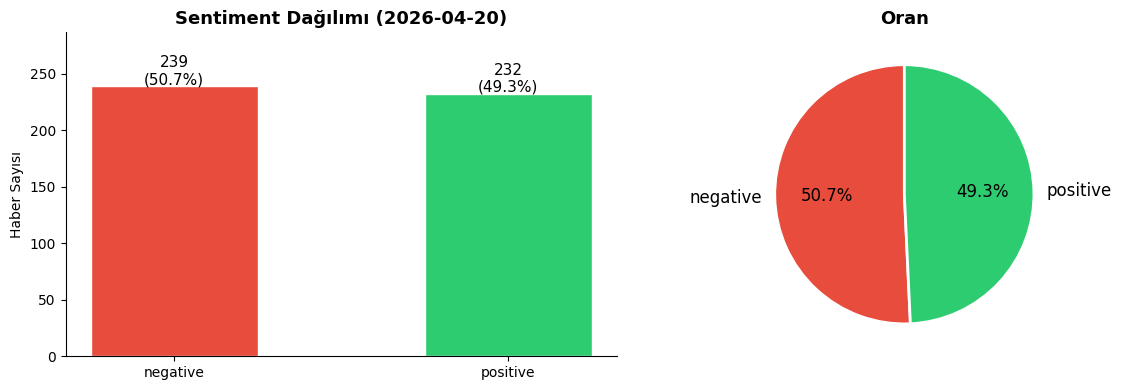

In [9]:
tr = df[df["is_turkish"] == True].copy()
label_counts = tr["sentiment_label"].value_counts()

COLORS = {"positive": "#2ecc71", "neutral": "#95a5a6", "negative": "#e74c3c"}
bar_colors = [COLORS.get(l, "#bdc3c7") for l in label_counts.index]

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Bar chart
axes[0].bar(label_counts.index, label_counts.values, color=bar_colors, edgecolor="white", width=0.5)
for i, (label, val) in enumerate(zip(label_counts.index, label_counts.values)):
    axes[0].text(i, val + 2, f"{val}\n({val/len(tr)*100:.1f}%)", ha="center", fontsize=11)
axes[0].set_title(f"Sentiment Dağılımı ({DATE})", fontsize=13, fontweight="bold")
axes[0].set_ylabel("Haber Sayısı")
axes[0].set_ylim(0, label_counts.max() * 1.2)
axes[0].spines[["top", "right"]].set_visible(False)

# Pie chart
wedge_colors = [COLORS.get(l, "#bdc3c7") for l in label_counts.index]
axes[1].pie(
    label_counts.values,
    labels=label_counts.index,
    colors=wedge_colors,
    autopct="%1.1f%%",
    startangle=90,
    wedgeprops={"edgecolor": "white", "linewidth": 2},
    textprops={"fontsize": 12},
)
axes[1].set_title("Oran", fontsize=13, fontweight="bold")

plt.tight_layout()
plt.savefig(REPO_ROOT / "notebooks" / "sentiment_distribution.png", dpi=150, bbox_inches="tight")
plt.show()

## 2 · Kaynağa Göre Sentiment

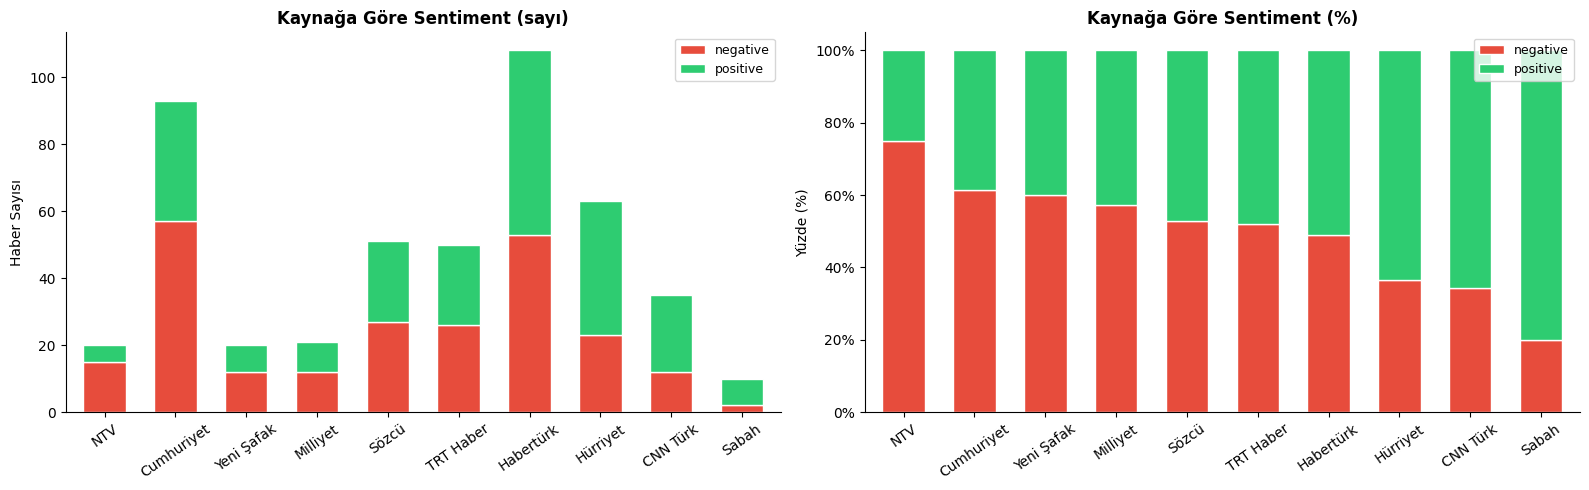

In [10]:
pivot = (
    tr.groupby(["source_name", "sentiment_label"])
    .size()
    .unstack(fill_value=0)
)
# normalize to % per source
pivot_pct = pivot.div(pivot.sum(axis=1), axis=0) * 100
pivot_pct = pivot_pct.sort_values("negative", ascending=False)

col_colors = [COLORS.get(c, "#bdc3c7") for c in pivot_pct.columns]

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# stacked bar — absolute counts
pivot.loc[pivot_pct.index].plot(
    kind="bar", stacked=True, ax=axes[0],
    color=col_colors, edgecolor="white", width=0.6
)
axes[0].set_title("Kaynağa Göre Sentiment (sayı)", fontsize=12, fontweight="bold")
axes[0].set_xlabel("")
axes[0].set_ylabel("Haber Sayısı")
axes[0].tick_params(axis="x", rotation=35)
axes[0].legend(loc="upper right", fontsize=9)
axes[0].spines[["top", "right"]].set_visible(False)

# stacked bar — percentage
pivot_pct.plot(
    kind="bar", stacked=True, ax=axes[1],
    color=col_colors, edgecolor="white", width=0.6
)
axes[1].set_title("Kaynağa Göre Sentiment (%)", fontsize=12, fontweight="bold")
axes[1].set_xlabel("")
axes[1].set_ylabel("Yüzde (%)")
axes[1].yaxis.set_major_formatter(mticker.PercentFormatter())
axes[1].tick_params(axis="x", rotation=35)
axes[1].legend(loc="upper right", fontsize=9)
axes[1].spines[["top", "right"]].set_visible(False)

plt.tight_layout()
plt.savefig(REPO_ROOT / "notebooks" / "sentiment_by_source.png", dpi=150, bbox_inches="tight")
plt.show()

## 3 · En Sık Entity'ler (PER / ORG / LOC)

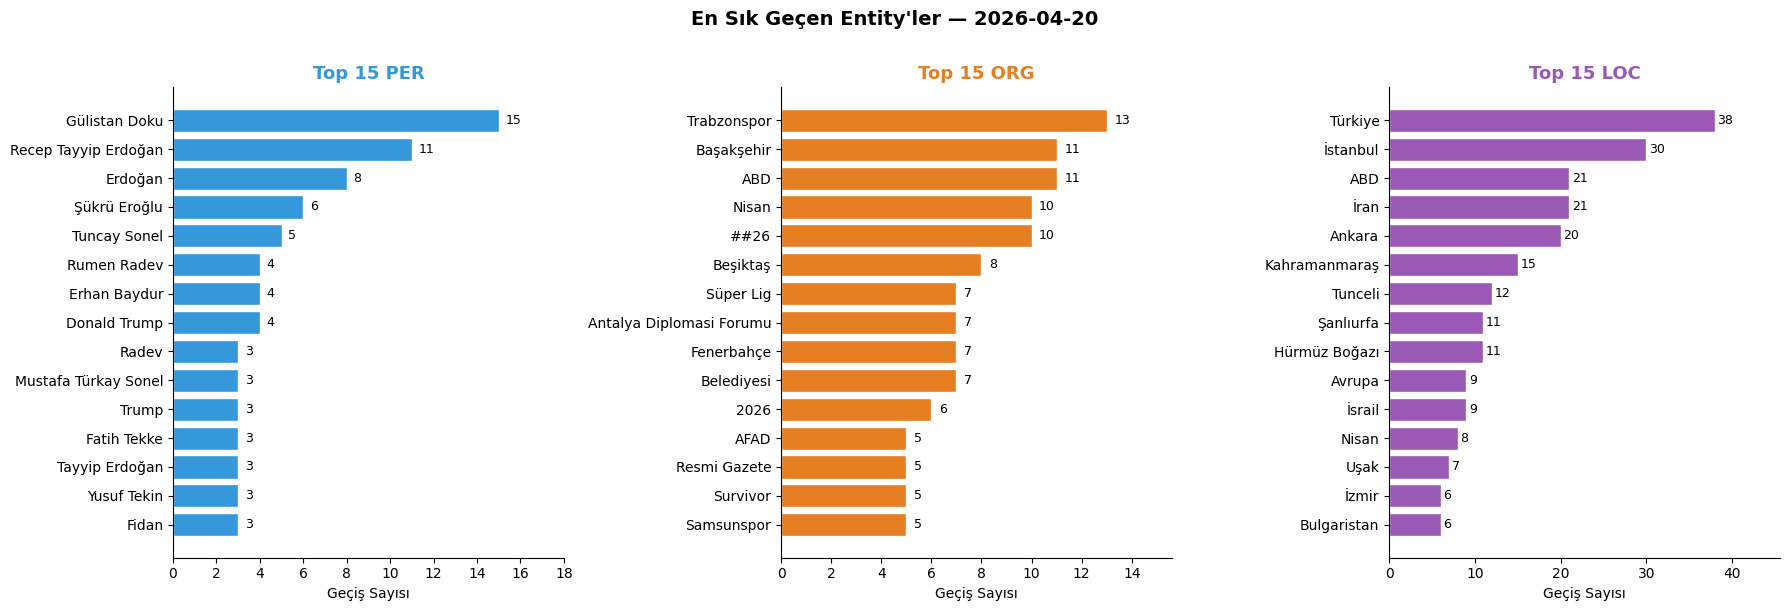

In [11]:
entity_counts = {"PER": Counter(), "ORG": Counter(), "LOC": Counter()}

for item in items:
    ents = item.get("entities") or {}
    for label, words in ents.items():
        if label in entity_counts:
            entity_counts[label].update(words)

TOP_N = 15
ENTITY_COLORS = {"PER": "#3498db", "ORG": "#e67e22", "LOC": "#9b59b6"}

fig, axes = plt.subplots(1, 3, figsize=(18, 6))

for ax, (label, counter) in zip(axes, entity_counts.items()):
    top = counter.most_common(TOP_N)
    if not top:
        ax.set_visible(False)
        continue
    names, counts = zip(*top)
    bars = ax.barh(names[::-1], counts[::-1], color=ENTITY_COLORS[label], edgecolor="white")
    for bar, cnt in zip(bars, counts[::-1]):
        ax.text(bar.get_width() + 0.3, bar.get_y() + bar.get_height() / 2,
                str(cnt), va="center", fontsize=9)
    ax.set_title(f"Top {TOP_N} {label}", fontsize=13, fontweight="bold",
                 color=ENTITY_COLORS[label])
    ax.set_xlabel("Geçiş Sayısı")
    ax.spines[["top", "right"]].set_visible(False)
    ax.set_xlim(0, counts[0] * 1.2)

plt.suptitle(f"En Sık Geçen Entity'ler — {DATE}", fontsize=14, fontweight="bold", y=1.01)
plt.tight_layout()
plt.savefig(REPO_ROOT / "notebooks" / "top_entities.png", dpi=150, bbox_inches="tight")
plt.show()

## 4 · Cluster Büyüklükleri ve Anahtar Kelimeler

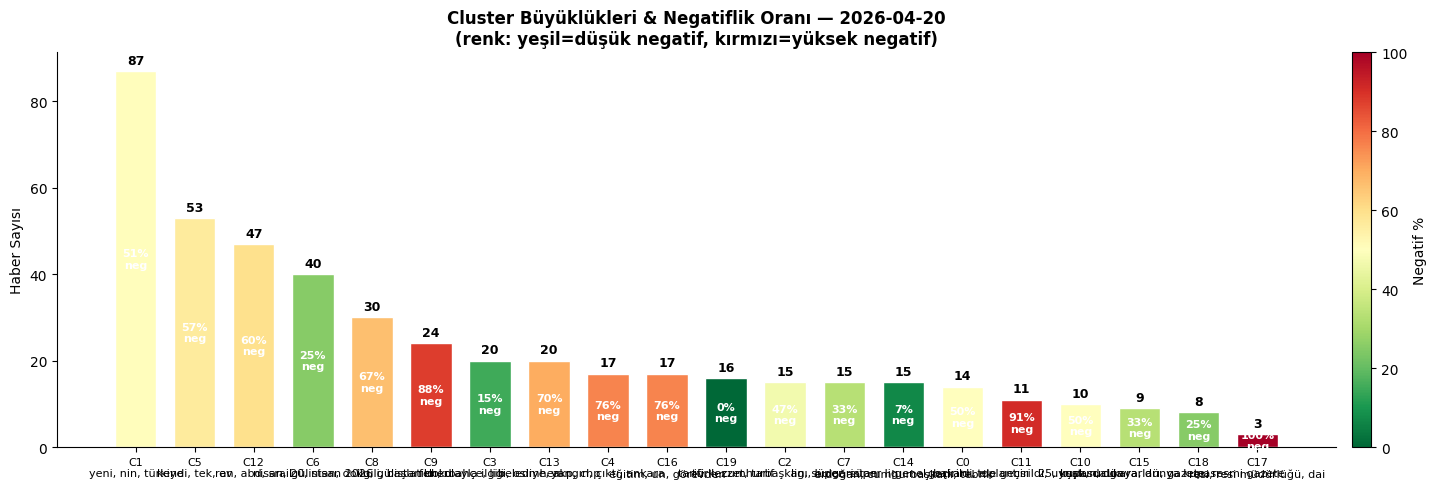


Cluster Detayları:
  ID  Boyut   Neg%  Anahtar Kelimeler
-----------------------------------------------------------------
   1     87    50.6%  yeni, nin, türkiye, ilk, attı
   5     53    56.6%  kendi, tek, ev, fatih, değil
  12     47    59.6%  ran, abd, srail, el, hürmüz
   6     40    25.0%  nisan, 20, nisan 2026, 20 nisan, 2026
   8     30    66.7%  gülistan, doku, gülistan doku, sonel, son
   9     24    87.5%  ilgili, başlatıldı, olayla ilgili, olayla, kişi
   3     20    15.0%  fenerbahçe, ligi, osimhen, fenerbahçe opet, opet
  13     20    70.0%  belediye, akp, chp, li, belediye başkanı
   4     17    76.5%  yangın, çıktı, ankara, yangın çıktı, sincan
  16     17    76.5%  eğitim, un, görevden, milli, kahramanmaraş
  19     16     0.0%  tarifi, lezzet, tarif, videolu, klasik
   2     15    46.7%  türk, cumhurbaşkanı, bulgaristan, eski cumhurbaşkanı, eski
   7     15    33.3%  lig, süper, süper lig, haftasında, 30 haftasında
  14     15     6.7%  erdoğan, cumhurbaşkanı, tebri

In [12]:
clusters_sorted = sorted(clusters, key=lambda x: x["size"], reverse=True)
labels_c = [f"C{c['cluster_id']}\n{', '.join(c['keywords'][:3])}" for c in clusters_sorted]
sizes    = [c["size"] for c in clusters_sorted]
neg_pcts = [
    c["sentiment_distribution"].get("negative", 0) / c["size"] * 100
    for c in clusters_sorted
]

cmap = plt.cm.RdYlGn_r
bar_colors_c = [cmap(p / 100) for p in neg_pcts]

fig, ax = plt.subplots(figsize=(16, 5))
bars = ax.bar(range(len(clusters_sorted)), sizes, color=bar_colors_c, edgecolor="white", width=0.7)

for i, (bar, s, neg) in enumerate(zip(bars, sizes, neg_pcts)):
    ax.text(i, s + 1, f"{s}", ha="center", va="bottom", fontsize=9, fontweight="bold")
    ax.text(i, s / 2, f"{neg:.0f}%\nneg", ha="center", va="center",
            fontsize=8, color="white", fontweight="bold")

ax.set_xticks(range(len(clusters_sorted)))
ax.set_xticklabels(labels_c, fontsize=8)
ax.set_ylabel("Haber Sayısı")
ax.set_title(
    f"Cluster Büyüklükleri & Negatiflik Oranı — {DATE}\n"
    "(renk: yeşil=düşük negatif, kırmızı=yüksek negatif)",
    fontsize=12, fontweight="bold"
)
ax.spines[["top", "right"]].set_visible(False)

sm = plt.cm.ScalarMappable(cmap=cmap, norm=plt.Normalize(0, 100))
sm.set_array([])
plt.colorbar(sm, ax=ax, label="Negatif %", pad=0.01)

plt.tight_layout()
plt.savefig(REPO_ROOT / "notebooks" / "cluster_sizes.png", dpi=150, bbox_inches="tight")
plt.show()

print("\nCluster Detayları:")
print(f"{'ID':>4} {'Boyut':>6} {'Neg%':>6}  Anahtar Kelimeler")
print("-" * 65)
for c in clusters_sorted:
    neg = c["sentiment_distribution"].get("negative", 0) / c["size"] * 100
    kws = ", ".join(c["keywords"][:5])
    print(f"  {c['cluster_id']:>2}   {c['size']:>4}   {neg:>5.1f}%  {kws}")

## 5 · t-SNE Cluster Haritası

TF-IDF vektörlerini 2 boyuta indirgeleyip cluster'ları renklendir.  
Her nokta bir haber, renk cluster ID'si, yıldız = en yüksek entity_count.

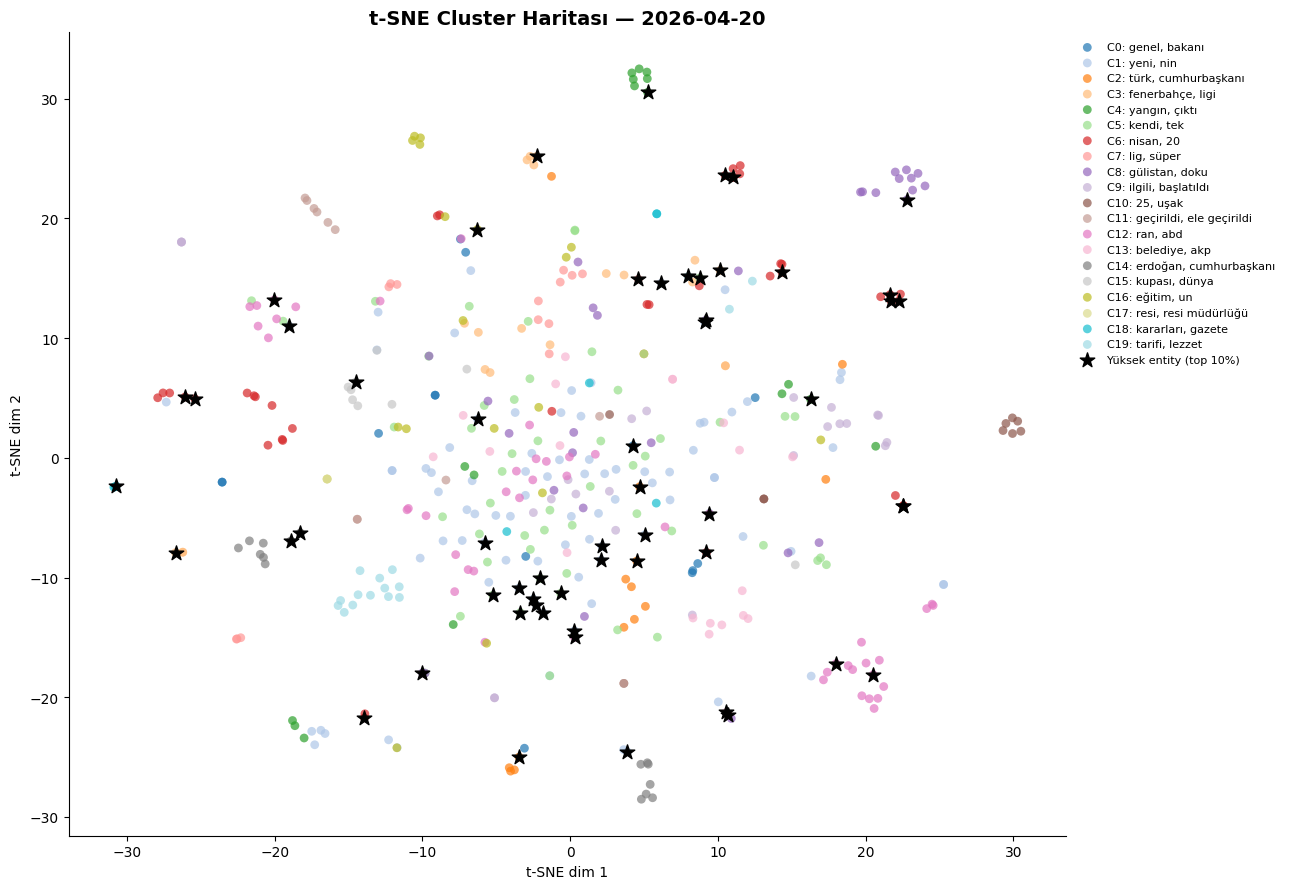

In [14]:
tr_df = df[df["is_turkish"] == True].copy().reset_index(drop=True)
texts  = (tr_df["cleaned_title"].fillna("") + " " + tr_df["cleaned_summary"].fillna("")).str.strip()
cids   = tr_df["cluster_id"].fillna(-1).astype(int).values

# TF-IDF → SVD (50 dim) → t-SNE (2 dim)
vec = TfidfVectorizer(max_features=3000, sublinear_tf=True, min_df=2)
X   = vec.fit_transform(texts)
X50 = TruncatedSVD(n_components=50, random_state=42).fit_transform(X)
X2  = TSNE(n_components=2, random_state=42, perplexity=30, max_iter=1000).fit_transform(X50)

palette = plt.cm.tab20.colors
unique_cids = sorted(set(cids))

fig, ax = plt.subplots(figsize=(13, 9))

for cid in unique_cids:
    mask = cids == cid
    color = palette[cid % len(palette)] if cid >= 0 else "#cccccc"
    kws = next((c["keywords"][:2] for c in clusters if c["cluster_id"] == cid), [str(cid)])
    label = f"C{cid}: {', '.join(kws)}"
    ax.scatter(X2[mask, 0], X2[mask, 1], c=[color], label=label,
               alpha=0.7, s=40, edgecolors="none")

# highlight high-entity items
entity_counts_col = tr_df["entity_count"].fillna(0).values
threshold = np.percentile(entity_counts_col, 90)
high_mask = entity_counts_col >= threshold
ax.scatter(X2[high_mask, 0], X2[high_mask, 1],
           marker="*", s=120, c="black", zorder=5, label="Yüksek entity (top 10%)")

ax.set_title(f"t-SNE Cluster Haritası — {DATE}", fontsize=14, fontweight="bold")
ax.set_xlabel("t-SNE dim 1")
ax.set_ylabel("t-SNE dim 2")
ax.legend(loc="upper left", bbox_to_anchor=(1, 1), fontsize=8, frameon=False)
ax.spines[["top", "right"]].set_visible(False)

plt.tight_layout()
plt.savefig(REPO_ROOT / "notebooks" / "tsne_clusters.png", dpi=150, bbox_inches="tight")
plt.show()